In [13]:
# ============================================================
# Imports
# ============================================================
import os
import cv2
import zipfile
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from tqdm import tqdm
from IPython.display import FileLink, display


In [14]:
# ============================================================
# Configuration
# ============================================================
BASE_DIR = "/kaggle/input/brisc2025/brisc2025/classification_task"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

CLASSES = ["glioma", "meningioma", "no_tumor", "pituitary"]
N_CLASSES = len(CLASSES)
CLASS_MAP = {c: i for i, c in enumerate(CLASSES)}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 24
EPOCHS = 100
LR = 1e-4
PATIENCE = 7


In [15]:
# ============================================================
# Data Loading
# ============================================================
def load_data(root, size=(224, 224)):
    X, y = [], []
    for cls in CLASSES:
        path = os.path.join(root, cls)
        label = CLASS_MAP[cls]
        for f in os.listdir(path):
            img = cv2.imread(os.path.join(path, f))
            if img is None:
                continue
            img = cv2.resize(img, size)
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = load_data(TRAIN_DIR)
X_test,  y_test  = load_data(TEST_DIR)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (5000, 224, 224, 3) (5000,)
Test : (1000, 224, 224, 3) (1000,)


In [16]:
# ============================================================
# Transforms
# ============================================================
train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# ============================================================
# Dataset
# ============================================================
class BrainTumorDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.uint8)
        img = self.transform(img)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return img, label


train_loader = DataLoader(
    BrainTumorDataset(X_train, y_train, train_tfms),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    BrainTumorDataset(X_test, y_test, test_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [11]:
# ============================================================
# Model: Vision Transformer
# ============================================================
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=N_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# ============================================================
# Training with Early Stopping
# ============================================================
train_acc, val_acc = [], []
train_loss, val_loss = [], []

best_val_acc = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    total, correct, loss_sum = 0, 0, 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x).logits
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss.append(loss_sum / total)
    train_acc.append(correct / total)

    # -------- VALIDATION --------
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x).logits
            loss = criterion(logits, y)

            loss_sum += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss.append(loss_sum / total)
    val_acc.append(correct / total)

    print(f"[{epoch+1:03d}] train_acc={train_acc[-1]:.4f} val_acc={val_acc[-1]:.4f}")

    # -------- EARLY STOPPING --------
    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        patience_counter = 0
        torch.save(model.state_dict(), "best_vit_model.pth")
        print("✅ Best model saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:
        print("⏹ Early stopping triggered")
        break

model.load_state_dict(torch.load("best_vit_model.pth"))


Epoch 1/100 [Train]: 100%|██████████| 209/209 [03:17<00:00,  1.06it/s]


[001] train_acc=0.9322 val_acc=0.9630
✅ Best model saved


Epoch 2/100 [Train]: 100%|██████████| 209/209 [03:22<00:00,  1.03it/s]


[002] train_acc=0.9672 val_acc=0.9810
✅ Best model saved


Epoch 3/100 [Train]: 100%|██████████| 209/209 [03:22<00:00,  1.03it/s]


...

Epoch 15/100 [Train]: 100%|██████████| 209/209 [03:23<00:00,  1.03it/s]


[015] train_acc=0.9942 val_acc=0.9930
⚠️ No improvement (6/7)


Epoch 16/100 [Train]: 100%|██████████| 209/209 [03:23<00:00,  1.03it/s]


[016] train_acc=0.9942 val_acc=0.9890
⚠️ No improvement (7/7)
⏹ Early stopping triggered


<All keys matched successfully>

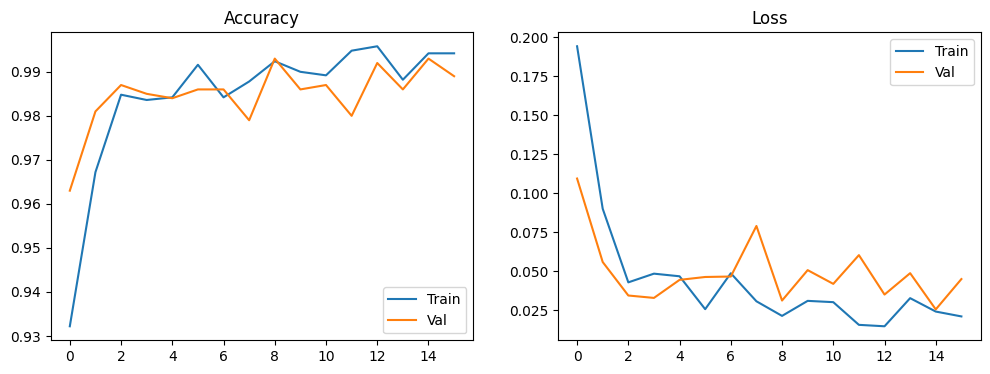

In [18]:
# ============================================================
# Training Curves
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Accuracy")
plt.legend(["Train", "Val"])

plt.subplot(1,2,2)
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Loss")
plt.legend(["Train", "Val"])

plt.show()


              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99       254
  meningioma       0.99      0.99      0.99       306
    no_tumor       0.98      1.00      0.99       140
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Accuracy : 0.993
Precision: 0.9911551161792242
Recall   : 0.9940647676393393
F1-score : 0.9925742379939282


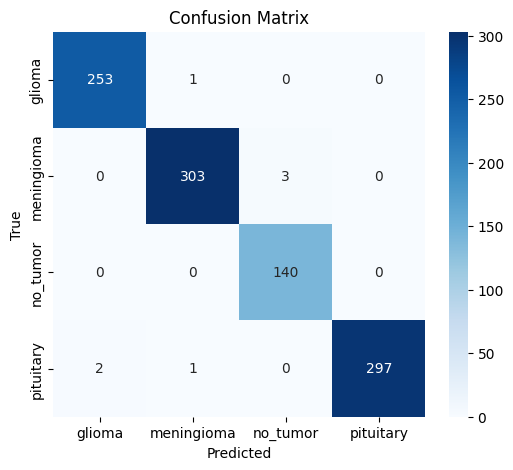

In [19]:
# ============================================================
# Evaluation
# ============================================================
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        preds = model(x).logits.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

print(classification_report(y_true, y_pred, target_names=CLASSES))

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall   :", recall_score(y_true, y_pred, average="macro"))
print("F1-score :", f1_score(y_true, y_pred, average="macro"))


# ============================================================
# Confusion Matrix (Blue)
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [20]:
# ============================================================
# Save Results & Download ZIP
# ============================================================

pred_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
})
pred_path = "/kaggle/working/predictions.csv"
pred_df.to_csv(pred_path, index=False)

metrics_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
).transpose().round(4)

metrics_path = "/kaggle/working/metrics.csv"
metrics_df.to_csv(metrics_path)

cm_path = "/kaggle/working/confusion_matrix.npy"
np.save(cm_path, cm)

zip_path = "/kaggle/working/vit_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(pred_path, "predictions.csv")
    zipf.write(metrics_path, "metrics.csv")
    zipf.write(cm_path, "confusion_matrix.npy")

display(FileLink(zip_path))


/kaggle/working/vit_results.zip